In [ ]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Defining the ODE
def func(x):
    return x*np.sin(5*x)

In [6]:
geom = dde.geometry.Interval(-1, 1) # computationla domain

In [8]:
num_train = 16 # Number of sensor point
num_test = 100

In [12]:
data = dde.data.Function(
    geom,
    func,
    num_train,
    num_test
)


net = dde.nn.FNN(
    [1] + [20]*3 + [1],
    activation="tanh",
    kernel_initializer="Glorot uniform"
)

In [15]:
model = dde.Model(data, net)

model.compile("adam", lr=0.001, metrics=["l2 relative error"])
history, train_state = model.train(iterations=10000)

Compiling model...
'compile' took 0.008792 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [2.46e-01]    [2.09e-01]    [1.00e+00]    
1000      [1.34e-03]    [1.10e-03]    [7.24e-02]    
2000      [5.54e-04]    [4.95e-04]    [4.87e-02]    
3000      [7.77e-05]    [1.05e-04]    [2.24e-02]    
4000      [6.97e-06]    [4.54e-05]    [1.47e-02]    
5000      [4.15e-06]    [4.37e-05]    [1.45e-02]    
6000      [5.19e-06]    [3.75e-05]    [1.34e-02]    
7000      [2.89e-07]    [3.31e-05]    [1.26e-02]    
8000      [2.66e-05]    [5.29e-05]    [1.59e-02]    
9000      [4.39e-08]    [3.07e-05]    [1.21e-02]    
10000     [3.51e-08]    [3.02e-05]    [1.20e-02]    

Best model at step 10000:
  train loss: 3.51e-08
  test loss: 3.02e-05
  test metric: [1.20e-02]

'train' took 15.085641 s



Relative error : 0.0120


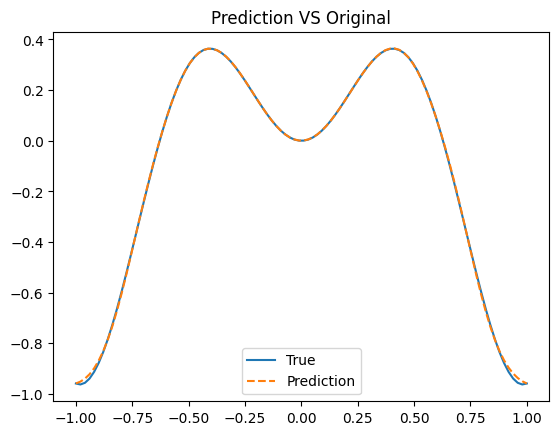

In [21]:
x_test = np.linspace(-1, 1, 100).reshape(-1, 1)

y_true = func(x_test)
y_pred = model.predict(x_test)

l2_error = (np.linalg.norm(y_true-y_pred)) / np.linalg.norm(y_true)
print(f"Relative error : {l2_error:0.4f}")


plt.figure()
plt.plot(x_test, y_true, label="True")
plt.plot(x_test, y_pred, linestyle="--", label="Prediction")
plt.legend()
plt.title("Prediction VS Original")
plt.show()


In [29]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

def dy_dx(x):
    return (3*np.sin(2*x)) + (4*np.cos(6*x))

geom = dde.geometry.Interval(-5, 5)
num_train=200
num_test=500


data = dde.data.Function(
    geom,
    dy_dx,
    num_train,
    num_test
)

net = dde.nn.FNN(
    [1] + [20]*5 + [1],
    activation="tanh",
    kernel_initializer="Glorot uniform"
)



model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["l2 relative error"])
history, train_stte = model.train(iterations=10000)


Compiling model...
'compile' took 0.003980 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [1.22e+01]    [1.22e+01]    [9.99e-01]    
1000      [5.91e-01]    [5.56e-01]    [2.13e-01]    
2000      [7.43e-02]    [6.74e-02]    [7.42e-02]    
3000      [3.29e-02]    [3.16e-02]    [5.08e-02]    
4000      [6.41e-03]    [5.84e-03]    [2.19e-02]    
5000      [3.96e-02]    [3.96e-02]    [5.69e-02]    
6000      [5.73e-03]    [5.55e-03]    [2.13e-02]    
7000      [1.81e-03]    [1.76e-03]    [1.20e-02]    
8000      [1.42e-02]    [1.41e-02]    [3.39e-02]    
9000      [1.88e-02]    [1.87e-02]    [3.90e-02]    
10000     [9.67e-04]    [9.47e-04]    [8.80e-03]    

Best model at step 10000:
  train loss: 9.67e-04
  test loss: 9.47e-04
  test metric: [8.80e-03]

'train' took 18.166924 s



Relative error : 0.0026


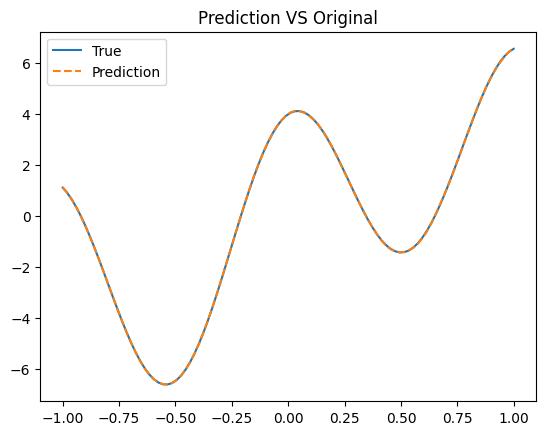

In [31]:
x_test = np.linspace(-1, 1, 100).reshape(-1, 1)

y_true = dy_dx(x_test)
y_pred = model.predict(x_test)

l2_error = (np.linalg.norm(y_true-y_pred)) / np.linalg.norm(y_true)
print(f"Relative error : {l2_error:0.4f}")


plt.figure()
plt.plot(x_test, y_true, label="True")
plt.plot(x_test, y_pred, linestyle="--", label="Prediction")
plt.legend()
plt.title("Prediction VS Original")
plt.show()